# Alcohol Consumption and Development Indicators

## DSA210 Final Project

### İdil Gülergün

This project investigates whether
alcohol consumption is related to development indicators such as GDP per capita and life expectancy between 2010 and 2020.

The study includes:
- Data collection and preprocessing
- Exploratory Data Analysis (EDA)
- Statistical hypothesis testing
- Machine learning classification models

In [1]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import pandas as pd

# -----------------------------
# 1. LOAD DATA
# -----------------------------
alcohol_raw = pd.read_csv("alcohol per capita country year csv.csv")
gdp_raw = pd.read_csv("API_NY.GDP.PCAP.CD_DS2_en_csv_v2_245.csv", skiprows=4)
life_raw = pd.read_csv("API_SP.DYN.LE00.IN_DS2_en_csv_v2_163.csv", skiprows=4)

# -----------------------------
# 2. CLEAN ALCOHOL DATA
# -----------------------------
alcohol = alcohol_raw.copy()

# Keep only countries & both sexes
alcohol = alcohol[alcohol["Location type"] == "Country"]
alcohol = alcohol[alcohol["Dim1"] == "Both sexes"]

# Keep needed columns
alcohol = alcohol[["Location", "Period", "FactValueNumeric"]]

# Rename
alcohol = alcohol.rename(columns={
    "Location": "Country",
    "Period": "Year",
    "FactValueNumeric": "Alcohol"
})

# Convert types
alcohol["Year"] = pd.to_numeric(alcohol["Year"], errors="coerce")
alcohol["Alcohol"] = pd.to_numeric(alcohol["Alcohol"], errors="coerce")

# Drop missing
alcohol = alcohol.dropna()

# Filter years
alcohol = alcohol[(alcohol["Year"] >= 2010) & (alcohol["Year"] <= 2020)]

# -----------------------------
# 3. CLEAN GDP DATA
# -----------------------------
gdp = gdp_raw.copy()

gdp = gdp[["Country Name"] + list(gdp.columns[4:])]

gdp = gdp.melt(
    id_vars=["Country Name"],
    var_name="Year",
    value_name="GDP"
)

gdp = gdp.rename(columns={"Country Name": "Country"})

gdp = gdp[gdp["Year"].astype(str).str.isnumeric()]
gdp["Year"] = gdp["Year"].astype(int)

gdp["GDP"] = pd.to_numeric(gdp["GDP"], errors="coerce")

gdp = gdp.dropna()

gdp = gdp[(gdp["Year"] >= 2010) & (gdp["Year"] <= 2020)]

# Remove aggregates
gdp = gdp[~gdp["Country"].isin([
    "World", "High income", "Low income",
    "Upper middle income", "Lower middle income",
    "Middle income", "European Union"
])]

# -----------------------------
# 4. CLEAN LIFE EXPECTANCY
# -----------------------------
life = life_raw.copy()

life = life[["Country Name"] + list(life.columns[4:])]

life = life.melt(
    id_vars=["Country Name"],
    var_name="Year",
    value_name="LifeExp"
)

life = life.rename(columns={"Country Name": "Country"})

life = life[life["Year"].astype(str).str.isnumeric()]
life["Year"] = life["Year"].astype(int)

life["LifeExp"] = pd.to_numeric(life["LifeExp"], errors="coerce")

life = life.dropna()

life = life[(life["Year"] >= 2010) & (life["Year"] <= 2020)]

# Remove aggregates
life = life[~life["Country"].isin([
    "World", "High income", "Low income",
    "Upper middle income", "Lower middle income",
    "Middle income", "European Union"
])]

# -----------------------------
# 5. FIX COUNTRY NAMES
# -----------------------------
name_fixes = {
    "Turkiye": "Turkey",
    "Türkiye": "Turkey",
    "United States of America": "United States",
    "Russian Federation": "Russia",
    "Iran (Islamic Republic of)": "Iran",
    "Viet Nam": "Vietnam"
}

alcohol["Country"] = alcohol["Country"].replace(name_fixes)
gdp["Country"] = gdp["Country"].replace(name_fixes)
life["Country"] = life["Country"].replace(name_fixes)

# -----------------------------
# 6. MERGE DATA
# -----------------------------
df = pd.merge(alcohol, gdp, on=["Country", "Year"], how="inner")
df = pd.merge(df, life, on=["Country", "Year"], how="inner")

df = df.dropna()

# Save final dataset
df.to_csv("panel_dataset.csv", index=False)

# -----------------------------
# 7. FINAL CHECK
# -----------------------------
print(df.head())
print(df.shape)
# %%
print("Countries:", df["Country"].nunique())




       Country  Year  Alcohol          GDP  LifeExp
0   Bangladesh  2020    0.004  2248.850788   71.421
1  Afghanistan  2020    0.010   510.787063   61.454
2        Libya  2020    0.021  6650.338106   72.388
3   Mauritania  2020    0.008  1795.764596   66.794
4        Sudan  2020    0.011   577.795227   65.124
(1790, 5)
Countries: 164


# Data Collection and Preprocessing

The datasets used in this project were collected from:
- WHO alcohol consumption dataset
- World Bank GDP per capita dataset
- World Bank life expectancy dataset

The preprocessing stage included:
- filtering years between 2010 and 2020
- removing aggregate regions
- handling missing values
- standardizing country names
- merging datasets into a single panel dataset

In [2]:
# -----------------------------
# 8. EXPLORATORY DATA ANALYSIS (EDA)
# -----------------------------

df.head()

,Country,Year,Alcohol,GDP,LifeExp
0,Bangladesh,2020,0.004,2248.850788,71.421
1,Afghanistan,2020,0.010,510.787063,61.454
2,Libya,2020,0.021,6650.338106,72.388
3,Mauritania,2020,0.008,1795.764596,66.794
4,Sudan,2020,0.011,577.795227,65.124


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1790 entries, 0 to 1789
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Country  1790 non-null   object 
 1   Year     1790 non-null   int64  
 2   Alcohol  1790 non-null   float64
 3   GDP      1790 non-null   float64
 4   LifeExp  1790 non-null   float64
dtypes: float64(3), int64(1), object(1)
memory usage: 70.1+ KB


In [4]:
df.describe()

,Year,Alcohol,GDP,LifeExp
count,1790.000000,1790.000000,1790.000000,1790.000000
mean,2014.986592,5.563471,14001.732389,71.329480
std,3.164546,4.130737,19942.144145,8.300978
min,2010.000000,0.000200,216.727705,31.530000
25%,2012.000000,1.890000,1880.587010,65.339500
50%,2015.000000,4.990000,5831.029409,72.754695
75%,2018.000000,8.717500,15618.293626,77.528500
max,2020.000000,17.820000,123678.702143,84.560000


In [5]:
df.isnull().sum()

Country    0
Year       0
Alcohol    0
GDP        0
LifeExp    0
dtype: int64

In [6]:
df[["Alcohol", "GDP", "LifeExp"]].corr()

,Alcohol,GDP,LifeExp
Alcohol,1.000000,0.367670,0.386028
GDP,0.367670,1.000000,0.632622
LifeExp,0.386028,0.632622,1.000000


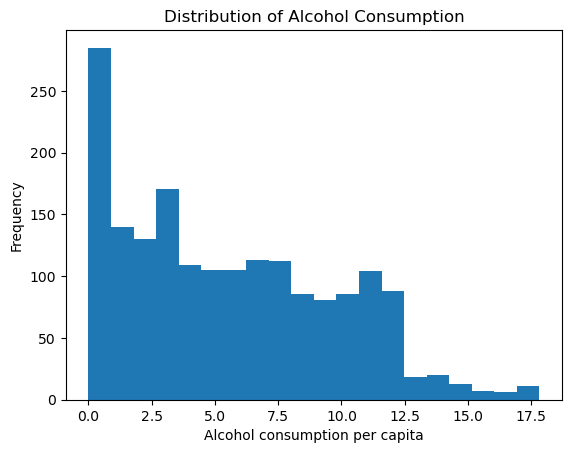

In [7]:
# -----------------------------
# 9. VISUALIZATIONS
# -----------------------------

import matplotlib.pyplot as plt

plt.hist(df["Alcohol"], bins=20)
plt.title("Distribution of Alcohol Consumption")
plt.xlabel("Alcohol consumption per capita")
plt.ylabel("Frequency")
plt.show()


The histogram shows the distribution of alcohol consumption across countries. Most countries are concentrated around lower to medium alcohol consumption levels, while fewer countries have extremely high consumption.

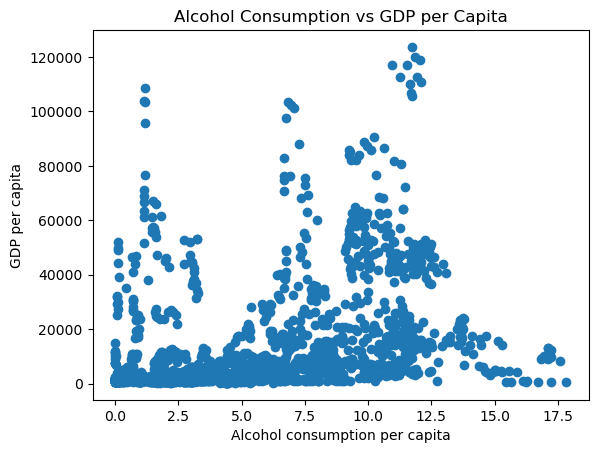

In [8]:
plt.scatter(df["Alcohol"], df["GDP"])
plt.title("Alcohol Consumption vs GDP per Capita")
plt.xlabel("Alcohol consumption per capita")
plt.ylabel("GDP per capita")
plt.show()

The scatterplot suggests a positive relationship between alcohol consumption and GDP per capita. Higher-income countries generally tend to report higher alcohol consumption levels.

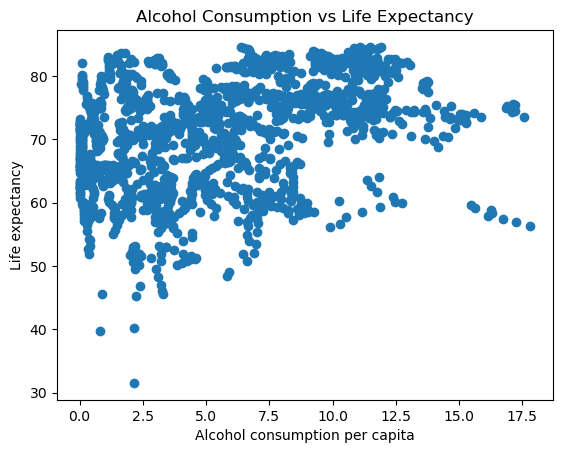

In [9]:
plt.scatter(df["Alcohol"], df["LifeExp"])
plt.title("Alcohol Consumption vs Life Expectancy")
plt.xlabel("Alcohol consumption per capita")
plt.ylabel("Life expectancy")
plt.show()

The visualization indicates a moderate positive relationship between alcohol consumption and life expectancy. Countries with higher life expectancy often also report higher alcohol consumption levels.

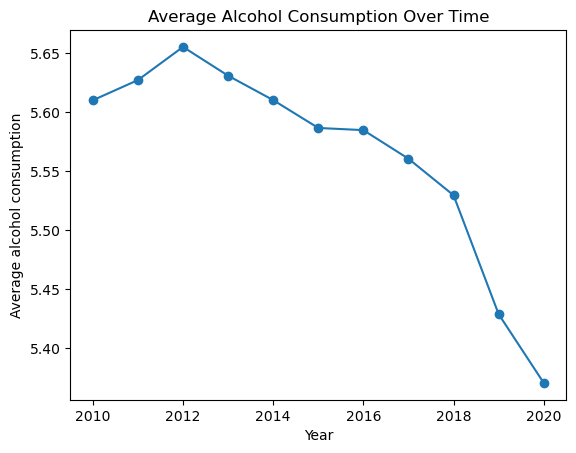

In [10]:
df.groupby("Year")["Alcohol"].mean().plot(marker="o")
plt.title("Average Alcohol Consumption Over Time")
plt.xlabel("Year")
plt.ylabel("Average alcohol consumption")
plt.show()

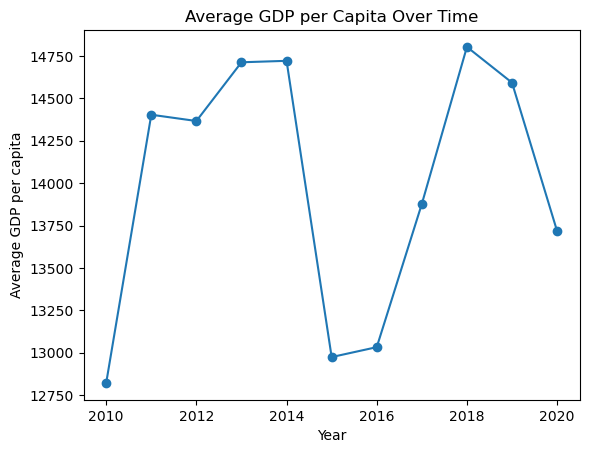

In [11]:
df.groupby("Year")["GDP"].mean().plot(marker="o")
plt.title("Average GDP per Capita Over Time")
plt.xlabel("Year")
plt.ylabel("Average GDP per capita")
plt.show()

The yearly averages show that alcohol consumption and GDP per capita remain relatively stable over time, with some fluctuations across years.

In [12]:
# -----------------------------
# 10. HYPOTHESIS TESTING
# -----------------------------

from scipy.stats import pearsonr

# Hypothesis 1:
# H0: There is no relationship between alcohol consumption and GDP per capita.
# H1: There is a relationship between alcohol consumption and GDP per capita.

corr_gdp, p_gdp = pearsonr(df["Alcohol"], df["GDP"])

print("Hypothesis Test 1: Alcohol vs GDP")
print("Correlation:", corr_gdp)
print("P-value:", p_gdp)

if p_gdp < 0.05:
    print("Result: Reject H0. There is a statistically significant relationship.")
else:
    print("Result: Fail to reject H0. There is no statistically significant relationship.")
    

Hypothesis Test 1: Alcohol vs GDP
Correlation: 0.3676700701395935
P-value: 2.087957747096617e-58
Result: Reject H0. There is a statistically significant relationship.


In [13]:
# Hypothesis 2:
# H0: There is no relationship between alcohol consumption and life expectancy.
# H1: There is a relationship between alcohol consumption and life expectancy.

corr_life, p_life = pearsonr(df["Alcohol"], df["LifeExp"])

print("Hypothesis Test 2: Alcohol vs Life Expectancy")
print("Correlation:", corr_life)
print("P-value:", p_life)

if p_life < 0.05:
    print("Result: Reject H0. There is a statistically significant relationship.")
else:
    print("Result: Fail to reject H0. There is no statistically significant relationship.")

Hypothesis Test 2: Alcohol vs Life Expectancy
Correlation: 0.38602813635489397
P-value: 1.0880355952170748e-64
Result: Reject H0. There is a statistically significant relationship.


## Hypothesis Testing Interpretation

The Pearson correlation tests produced statistically significant p-values below 0.05.

Therefore, the null hypotheses were rejected for both tests:
- alcohol vs GDP
- alcohol vs life expectancy

This suggests that alcohol consumption is significantly associated with development indicators.

In [14]:
# -----------------------------
# 11. MACHINE LEARNING: CLASSIFICATION
# -----------------------------

# Create a binary target variable:
# 1 = High life expectancy country
# 0 = Low life expectancy country

median_life = df["LifeExp"].median()

df["HighLifeExp"] = (df["LifeExp"] >= median_life).astype(int)

print("Median life expectancy:", median_life)
print(df["HighLifeExp"].value_counts())

Median life expectancy: 72.7546951219512
HighLifeExp
0    895
1    895
Name: count, dtype: int64


In [15]:
# Features and target

X = df[["Alcohol", "GDP"]]
y = df["HighLifeExp"]

# Train-test split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42,
    stratify=y
)

In [16]:
# Scale features for Logistic Regression

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [17]:
# Logistic Regression model

log_model = LogisticRegression()
log_model.fit(X_train_scaled, y_train)

log_pred = log_model.predict(X_test_scaled)

print("Logistic Regression Accuracy:", accuracy_score(y_test, log_pred))
print("\nClassification Report:")
print(classification_report(y_test, log_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, log_pred))

Logistic Regression Accuracy: 0.840782122905028

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.91      0.85       179
           1       0.90      0.77      0.83       179

    accuracy                           0.84       358
   macro avg       0.85      0.84      0.84       358
weighted avg       0.85      0.84      0.84       358


Confusion Matrix:
[[163  16]
 [ 41 138]]


In [18]:
# Decision Tree model

tree_model = DecisionTreeClassifier(random_state=42, max_depth=4)
tree_model.fit(X_train, y_train)

tree_pred = tree_model.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, tree_pred))
print("\nClassification Report:")
print(classification_report(y_test, tree_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, tree_pred))

Decision Tree Accuracy: 0.8575418994413407

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.85      0.86       179
           1       0.86      0.86      0.86       179

    accuracy                           0.86       358
   macro avg       0.86      0.86      0.86       358
weighted avg       0.86      0.86      0.86       358


Confusion Matrix:
[[153  26]
 [ 25 154]]


## Machine Learning Interpretation

For the machine learning part, I converted life expectancy into a binary classification problem. Countries with life expectancy above or equal to the median were labeled as high life expectancy countries, while countries below the median were labeled as low life expectancy countries.

I used alcohol consumption and GDP per capita as features. Two classification models were applied: Logistic Regression and Decision Tree Classifier. The models were evaluated using accuracy, classification report, and confusion matrix.

This classification approach helps examine whether development-related indicators can be used to distinguish countries with relatively high and low life expectancy.

## Model Comparison

Both Logistic Regression and Decision Tree models were able to classify countries according to life expectancy levels.

The Decision Tree model achieved slightly higher predictive performance, suggesting that nonlinear relationships may exist between the variables.

# Conclusion

This project analyzed whether alcohol consumption is related to development indicators such as GDP per capita and life expectancy between 2010 and 2020.

The preprocessing stage combined multiple international datasets into a unified panel dataset. Exploratory data analysis and visualizations suggested positive relationships between alcohol consumption and development indicators.

Pearson correlation hypothesis tests showed statistically significant relationships between:
- alcohol consumption and GDP per capita
- alcohol consumption and life expectancy

Additionally, machine learning classification models were trained to predict life expectancy categories using alcohol consumption and GDP features. Both Logistic Regression and Decision Tree models achieved meaningful predictive performance.

Overall, the results suggest that alcohol consumption is associated with development indicators, although correlation does not imply causation.

# Limitations and Future Work

This study has several limitations:
- correlation does not imply causation
- cultural and regional factors were not separately analyzed
- only a limited number of variables were included
- some countries may contain inconsistent reporting

Future studies could include:
- education indicators
- healthcare expenditure
- additional socioeconomic variables
- more advanced machine learning methods

# AI Assistance Disclosure

ChatGPT was used for debugging Python code, improving markdown explanations, brainstorming ideas, and learning GitHub/Jupyter workflow.

All final analysis decisions and interpretations were reviewed and completed by the student.